In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [2]:
#from pyha_analyzer import PyhaTrainer, PyhaTrainingArguments, extractors
from pyha_analyzer import extractors

2025-08-01 15:58:17.444712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754089097.461636 1255720 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754089097.466703 1255720 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754089097.481010 1255720 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754089097.481031 1255720 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754089097.481033 1255720 computation_placer.cc:177] computation placer alr

In [3]:
#you have 1148 williams nondegraded files that are getting broken into (60 seconds/5 seconds)= 12 spectograms each so a total of 13776 spectograms. Therefore, you can get 13776 Paola nondegraded files
#you have 300 williams degraded files that are getting broken into (60 seconds/5 seconds)= 12 spectograms each so a total of 3600 spectograms. Therefore, you can get (13776-3600) Paola degraded files so that degraded and nondegraded are equal
coralreef_extractor = extractors.MultiCoralReef()
coral_ads = coralreef_extractor("/home/s.kamboj.400/unzipped-coral/")
coral_ads

min size is 15538 from dataset Paola
sampling 15538 from (Paola, 0)
sampling 15538 from (Paola, 1)
sampling 1294 from (Williams_et_al_2024, 0)
sampling 1294 from (Williams_et_al_2024, 1)
Loaded: 33664 samples


Casting the dataset:   0%|          | 0/23564 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3030 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/7070 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'site', 'dataset'],
        num_rows: 23564
    })
    valid: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'site', 'dataset'],
        num_rows: 3030
    })
    test: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'site', 'dataset'],
        num_rows: 7070
    })
})

In [18]:
coral_ads["train"].features["labels"]

Sequence(feature=ClassLabel(names=['Paola', 'Williams_et_al_2024', 'Lin_et_al_2021'], id=None), length=-1, id=None)

In [6]:
coral_ads["train"][:50]

{'sample_rate': [48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000,
  48000],
 'labels': [[0, 1],
  [1, 0],
  [1, 0],
  [1, 0],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [0, 1],
  [1, 0],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [0, 1],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [1, 0],
  [1, 0],
  [0, 1],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [1, 0],
  [0, 1],
  [1, 0],
  [1, 0],
  [0, 1],
  [0, 1]],
 'filepath': ['/home/s.

In [ ]:
#from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors
#converts williams to many spectograms & paola to only one spectogram
from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors

# TODO: allow for normalization system

# preprocessor acts as a function for processing
# class allows us to configure parameters and whatnot
preprocessor = MelSpectrogramPreprocessors(duration=5, class_list=coral_ads["train"].features["labels"].feature.names)

coral_ads["train"].set_transform(preprocessor)
coral_ads["valid"].set_transform(preprocessor)
coral_ads["test"].set_transform(preprocessor)
coral_ads["train"][[0, 1]]["audio"][0].mean()

0.0361134

In [21]:
coral_ads["test"][0]

{'sample_rate': 48000,
 'labels': array([0., 0., 1.], dtype=float32),
 'filepath': '/home/s.kamboj.400/unzipped-coral/Paola/Degraded_Reef/April_2024_Pavonas/20240309_173500.WAV',
 'audio': array([[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.00392157, ..., 0.00784314,
          0.01176471, 0.01176471],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]], dtype=float32),
 'audio_in': array([[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.       

In [22]:
from pyha_analyzer.models import EfficentNet
#model = EfficentNet(num_classes=len(coral_ads["train"].features["ebird_code"].names))
model = EfficentNet(num_classes=3)

In [23]:
import torch
from pyha_analyzer import constants

torch.cuda.empty_cache()
args = PyhaTrainingArguments(
    working_dir="working_dir",
    run_name= constants.DEFAULT_RUN_NAME,
    project_name=constants.DEFAULT_PROJECT_NAME
)
args.num_train_epochs = 1
args.eval_steps = 20


trainer = PyhaTrainer(
    model=model,
    dataset=coral_ads,
    training_args=args,
)
trainer.train()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


MultilabelAveragePrecision init with num_labels  3  and average  none


OutOfMemoryError: CUDA out of memory. Tried to allocate 216.00 MiB. GPU 0 has a total capacity of 47.43 GiB of which 101.00 MiB is free. Process 3292851 has 45.95 GiB memory in use. Including non-PyTorch memory, this process has 1.36 GiB memory in use. Of the allocated memory 1.05 GiB is allocated by PyTorch, and 9.84 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# #Uncomment the following lines to save the git commit hash and model state_dict as pt file
# import subprocess
# import torch

# git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"]).decode().strip()

# with open("training_info.txt", "w") as f:
#     f.write(f"Git commit: {git_hash}\n")

# #save model in .pt file associated with git hash. This is useful for reproducibility, so that we can always refer back to the exact code used for training.
# model_save_path = f"balanced_williams_paola_coral_model_{git_hash[:7]}.pt"
# torch.save(trainer.model.state_dict(), model_save_path)

In [11]:
trainer.evaluate(eval_dataset=coral_ads["test"], metric_key_prefix="Soundscape")

{'Soundscape_loss': 0.29186975955963135,
 'Soundscape_cMAP': 0.9188719987869263,
 'Soundscape_ROCAUC': 0.9114878177642822,
 'Soundscape_runtime': 494.1856,
 'Soundscape_samples_per_second': 10.794,
 'Soundscape_steps_per_second': 0.338,
 'epoch': 1.0}

In [20]:
from scipy.stats import entropy

def compute_entropy(heatmap):
    h = np.clip(heatmap, 1e-8, None)
    h = h / np.sum(h)
    return entropy(h.flatten())

In [22]:
from pyha_analyzer.metrics.gradcam import GradCAM
import torch
from pyha_analyzer.models import EfficentNet
from pyha_analyzer import constants, PyhaTrainer, PyhaTrainingArguments
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# Rebuild and load model, need to do this rather than train on fake model; otherwise, outputs are wrong
newModel = EfficentNet(num_classes=2)
newModel.load_state_dict(torch.load("/home/s.kamboj.400/pyha-analyzer-2.0/saved-models/balanced_williams_paola_coral_model_524a67b.pt"))
newModel.eval()

# Rebuild trainer
args = PyhaTrainingArguments(
    working_dir="working_dir",
    run_name=constants.DEFAULT_RUN_NAME,
    project_name=constants.DEFAULT_PROJECT_NAME
)
args.num_train_epochs = 1
args.eval_steps = 20

trainer = PyhaTrainer(
    model=newModel,
    dataset=coral_ads,
    training_args=args,
)


target_layer = newModel.model.efficientnet.encoder.top_conv
print(target_layer)
gradcam = GradCAM(newModel.model, target_layer) # lets you use huggingface model code not the Pyha wrapper because you want to use that forward command


pdfPathDegraded = "Degraded_gradCAM.pdf"
pdfPathNonDegraded = "Non_Degraded_gradCAM.pdf" 
pDegraded = PdfPages(pdfPathDegraded) 
pNonDegraded = PdfPages(pdfPathNonDegraded)
countDegraded=0
countNonDegraded=0
numGradCams=199 # make it 99 to get 100 degraded & 100 non degraded
all_cam_pixels_degraded = []
all_cam_pixels_nondegraded = []
cam_entropies_degraded=[]
cam_entropies_nondegraded=[]

#cannot batch for grad cam
for i, item in enumerate(coral_ads["train"]):
    input_tensor = torch.tensor(item["audio_in"], dtype=torch.float32).unsqueeze(0)
    cam_output = gradcam.generate(input_tensor)
    cam_flat = cam_output.flatten()
    cam_entropy = compute_entropy(cam_flat)

    # generate (numGradCam +1) quantity of grad cams and save it in the pdf
    if ((countDegraded <=numGradCams) and (item["labels"] == [1,0]).all()):
        all_cam_pixels_degraded.extend(cam_flat)
        gradcam.show_gradcam_overlay(item, cam_output, pDegraded)
        cam_entropies_degraded.append(cam_entropy)
        countDegraded+=1
    elif ((countNonDegraded <=numGradCams) and (item["labels"] ==[ 0, 1]).all()):
        all_cam_pixels_nondegraded.extend(cam_flat)
        gradcam.show_gradcam_overlay(item, cam_output, pNonDegraded)
        cam_entropies_nondegraded.append(cam_entropy)
        countNonDegraded+=1
    if ((countNonDegraded > numGradCams) & (countDegraded > numGradCams)):
        break

pDegraded.close()
pNonDegraded.close()

#convert so that you can make histogram
degraded_vals = np.array(all_cam_pixels_degraded)
nondegraded_vals = np.array(all_cam_pixels_nondegraded)

np.save('balanced_run_degraded.npy', cam_entropies_degraded)
np.save('balanced_run_nondegraded.npy', cam_entropies_nondegraded)



MultilabelAveragePrecision init with num_labels  2  and average  none
Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), padding=same, bias=False)


/home/s.kamboj.400/pyha-analyzer-2.0/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/home/s.kamboj.400/pyha-analyzer-2.0/pyha_analyzer/metrics/gradcam.py:60: RuntimeWarning: invalid value encountered in divide
  spectrogram_resized = (spectrogram_resized - spectrogram_resized.min()) / \


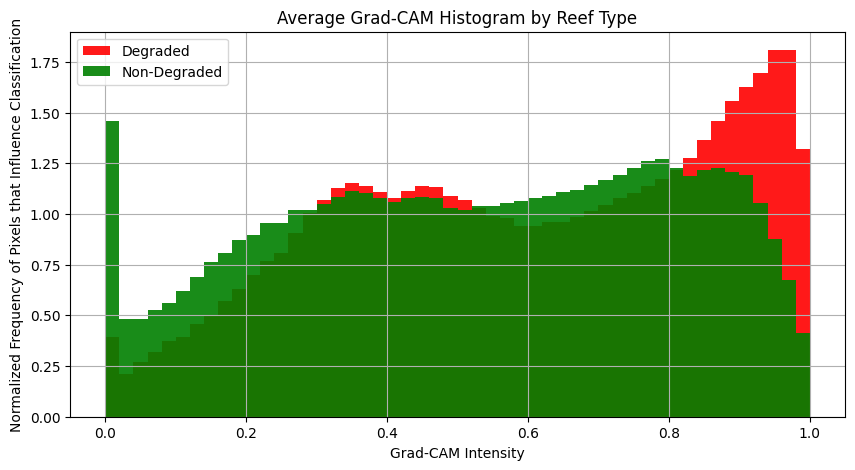

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(degraded_vals, bins=50, range=(0, 1), alpha=0.9, label="Degraded", color="red", density=True)
plt.hist(nondegraded_vals, bins=50, range=(0, 1), alpha=0.9, label="Non-Degraded", color="green", density=True)
plt.xlabel("Grad-CAM Intensity")
plt.ylabel("Normalized Frequency of Pixels that Influence Classification")
plt.title("Average Grad-CAM Histogram by Reef Type")
plt.legend()
plt.grid(True)
plt.show()

Balanced | Degraded: 10.707148 ± 0.034456838
Balanced | Non-degraded: 10.664426 ± 0.08895524
First Run | Degraded: 10.73434 ± 0.036917157
First Run | Non-degraded: 10.681153 ± 0.07146602


/tmp/ipykernel_2890819/2920968612.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


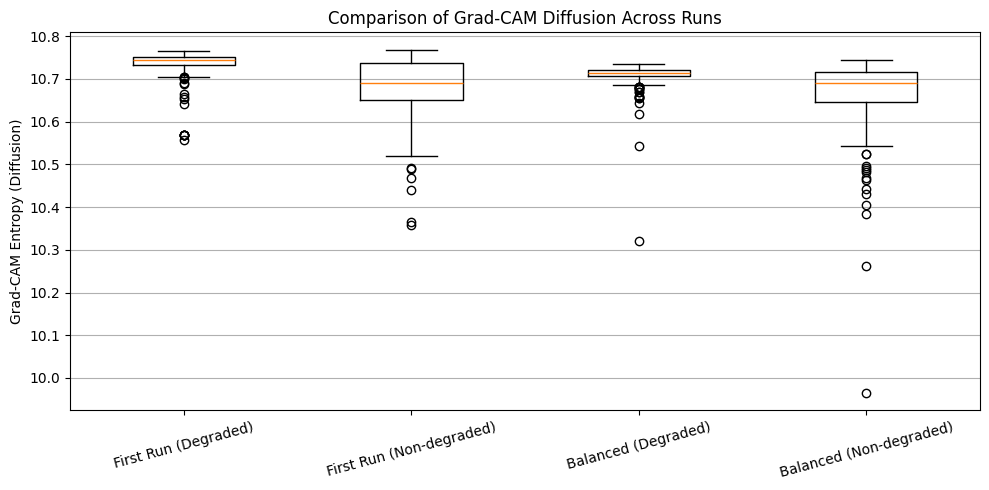

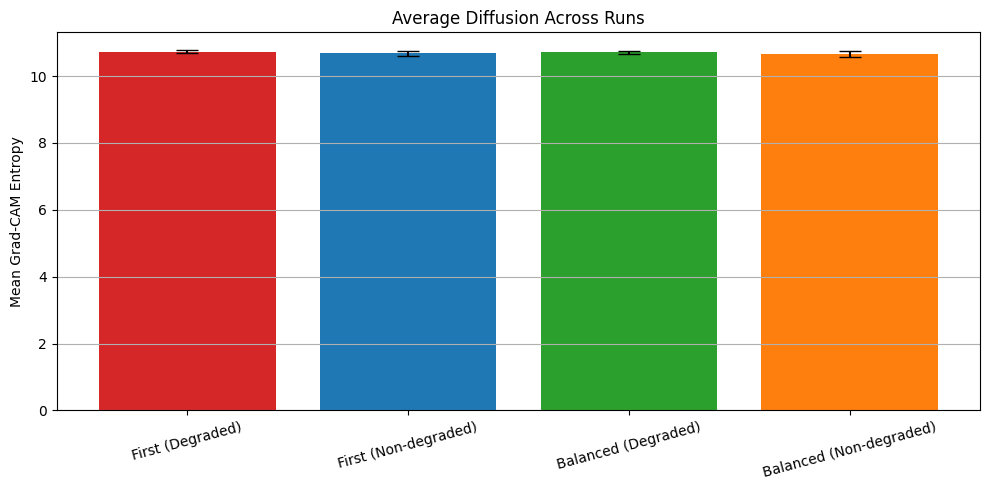

In [24]:
# Load entropy arrays
balanced_degraded = np.load("balanced_run_degraded.npy")
balanced_nondegraded = np.load("balanced_run_nondegraded.npy")
first_degraded = np.load("first_run_degraded.npy")
first_nondegraded = np.load("first_run_nondegraded.npy")

# Optional: print mean/std
print("Balanced | Degraded:", np.mean(balanced_degraded), "±", np.std(balanced_degraded))
print("Balanced | Non-degraded:", np.mean(balanced_nondegraded), "±", np.std(balanced_nondegraded))
print("First Run | Degraded:", np.mean(first_degraded), "±", np.std(first_degraded))
print("First Run | Non-degraded:", np.mean(first_nondegraded), "±", np.std(first_nondegraded))

# --- Boxplot: Distribution of Entropy Values ---
plt.figure(figsize=(10, 5))
plt.boxplot([
    first_degraded,
    first_nondegraded,
    balanced_degraded,
    balanced_nondegraded
], labels=[
    "First Run (Degraded)",
    "First Run (Non-degraded)",
    "Balanced (Degraded)",
    "Balanced (Non-degraded)"
])

plt.ylabel("Grad-CAM Entropy (Diffusion)")
plt.title("Comparison of Grad-CAM Diffusion Across Runs")
plt.xticks(rotation=15)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("cam_entropy_boxplot.png")
plt.show()

# --- Bar Plot: Mean Entropy with Error Bars ---
means = [
    np.mean(first_degraded),
    np.mean(first_nondegraded),
    np.mean(balanced_degraded),
    np.mean(balanced_nondegraded)
]
errors = [
    np.std(first_degraded),
    np.std(first_nondegraded),
    np.std(balanced_degraded),
    np.std(balanced_nondegraded)
]
labels = [
    "First (Degraded)",
    "First (Non-degraded)",
    "Balanced (Degraded)",
    "Balanced (Non-degraded)"
]

plt.figure(figsize=(10, 5))
plt.bar(labels, means, yerr=errors, capsize=8, color=["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"])
plt.ylabel("Mean Grad-CAM Entropy")
plt.title("Average Diffusion Across Runs")
plt.xticks(rotation=15)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("cam_entropy_barplot.png")
plt.show()

In [ ]:
#print(model.model) #make sure u get the last conv layer! check this to make sure

In [21]:
import lancedb
#Connect to LanceDB and save the embeddings
uri = "database/coral_reef_db.lance"
db = lancedb.connect(uri)

In [22]:
#delete the table for testing purposes, so that the same embeddings are not re-inserted because id is simply a key not a primary key, so embeddings can get reinserted
if "coral_embeddings" in db.table_names():
    #print("Table exists. If you run the next couple code blocks again, then you will get duplicate embeddings.")
    db.drop_table("coral_embeddings")

In [23]:
import pyarrow as pa
schema = pa.schema([
    pa.field("id", pa.string()),
    pa.field("vector_embedding", pa.list_(pa.float32(), list_size=1280)),
    pa.field("label", pa.string()),
    pa.field("audio_path", pa.string())
])
table = db.create_table("coral_embeddings", schema=schema)

In [16]:
import torch
batch_size = 32
table_rows=[]

for split in ["train", "valid"]:
    dataset = coral_ads[split]
    for i in range(0, len(dataset), batch_size):
        batch_items = dataset.select(range(i, min(i + batch_size, len(dataset))))

        # build input tensor
        batch_inputs = torch.stack([
            torch.tensor(item["audio_in"], dtype=torch.float32)
            for item in batch_items
        ])

        # get embeddings through batching
        embeddings = model.get_embedding(batch_inputs)

        # Loop through items and create metadata
        for j, (embedding, item) in enumerate(zip(embeddings, batch_items)):
            label_vec = item["labels"]
            if (label_vec == [0.0, 1.0]).all():
                curr_label = "Non_Degraded_Reef"
            elif (label_vec == [1.0, 0.0]).all():
                curr_label = "Degraded_Reef"
            else:
                curr_label = "Unknown"
                print("Unknown label:", label_vec)

            metadata = {
                "id": f"{split}{i + j}",
                "vector_embedding": embedding.tolist(),
                "label": curr_label,
                "audio_path": item["filepath"]
            }

            table_rows.append(metadata)

# Step 4: Insert all at once
table.add(table_rows)


AddResult(version=2)

In [17]:
# curr_split = "test"
# dataset = coral_ads[curr_split]
# batch_size = 16  

# for i in range(0, len(dataset), batch_size):
#     # Select a batch of size 16
#     batch_items = dataset.select(range(i, min(i + batch_size, len(dataset))))

#     # Create batched input tensor
#     batch_inputs = torch.stack([
#         torch.tensor(item["audio_in"], dtype=torch.float32)
#         for item in batch_items
#     ])  

#     # 3. Get embeddings for the batch of 16
#     embeddings = model.get_embedding(batch_inputs) 

#     # 4. Search LanceDB for each embedding
#     for item, embedding in zip(batch_items, embeddings):
#         query_vector = embedding.tolist()
#         results = table.search(query_vector).limit(1).to_pandas()

#         print("The most similar to", item["filepath"], "is", results["audio_path"].tolist()[0])
